In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib

In [11]:
df = pd.read_csv('insurance.csv')

In [12]:
df.tail(3)

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
1337,1338,30.0,male,34.5,91,Yes,3,Yes,northwest,60021.40
1338,1339,37.0,male,30.4,106,No,0,Yes,southeast,62592.87
1339,1340,30.0,female,47.4,101,No,0,Yes,southeast,63770.43


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1340 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1340 non-null   int64  
 1   age            1335 non-null   float64
 2   gender         1340 non-null   object 
 3   bmi            1340 non-null   float64
 4   bloodpressure  1340 non-null   int64  
 5   diabetic       1340 non-null   object 
 6   children       1340 non-null   int64  
 7   smoker         1340 non-null   object 
 8   region         1337 non-null   object 
 9   claim          1340 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 104.8+ KB


In [14]:
df.shape

(1340, 10)

In [15]:
pd.set_option("display.float_format","{:.2f}".format)

In [16]:
sns.set(style="whitegrid", palette="Set2", font_scale= 1.1)

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [19]:
df.dropna(inplace=True)

In [20]:
df.shape

(1332, 10)

In [21]:
df.isna().sum().sum()

np.int64(0)

In [22]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.00,1332.00,1332,1332.00,1332.00,1332,1332.00,1332,1332,1332.00
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.47,38.09,NaN,30.66,94.19,NaN,1.10,NaN,NaN,13325.25
std,384.70,11.11,NaN,6.12,11.45,NaN,1.21,NaN,NaN,12109.62
min,1.00,18.00,NaN,16.00,80.00,NaN,0.00,NaN,NaN,1121.87
25%,341.75,29.00,NaN,26.20,86.00,NaN,0.00,NaN,NaN,4760.16
50%,674.50,38.00,NaN,30.35,92.00,NaN,1.00,NaN,NaN,9412.97
75%,1007.25,47.00,NaN,34.73,99.00,NaN,2.00,NaN,NaN,16781.33


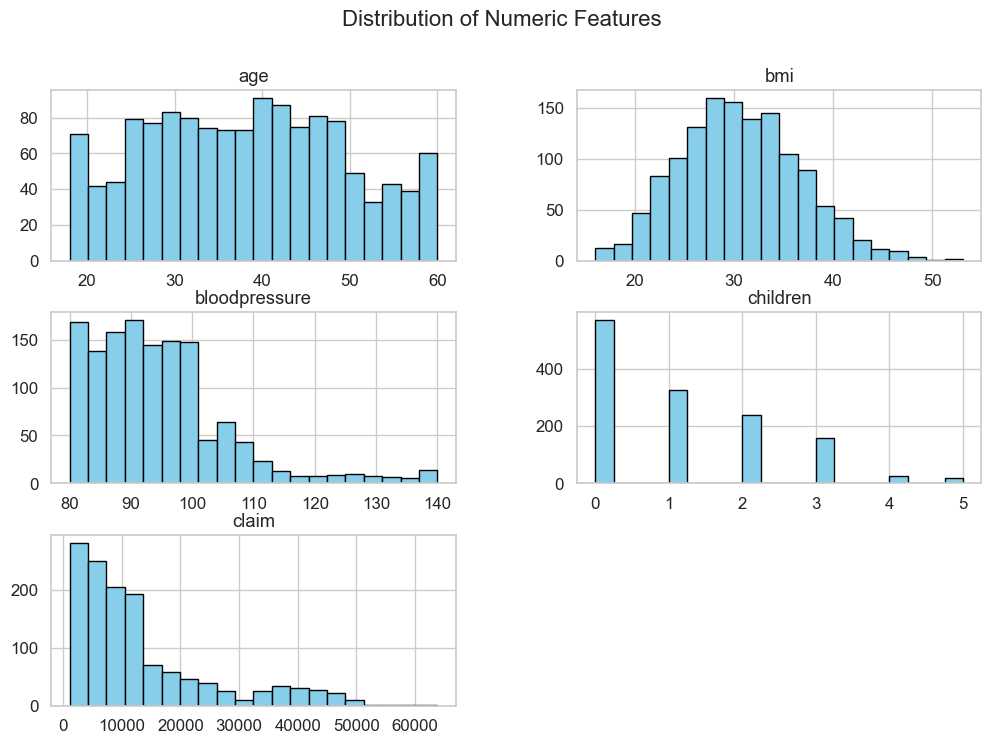

In [23]:
numeric_cols = ["age", "bmi", "bloodpressure", "children", "claim"]
df[numeric_cols].hist(bins=20, figsize=(12,8),color="skyblue",edgecolor = "black")
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

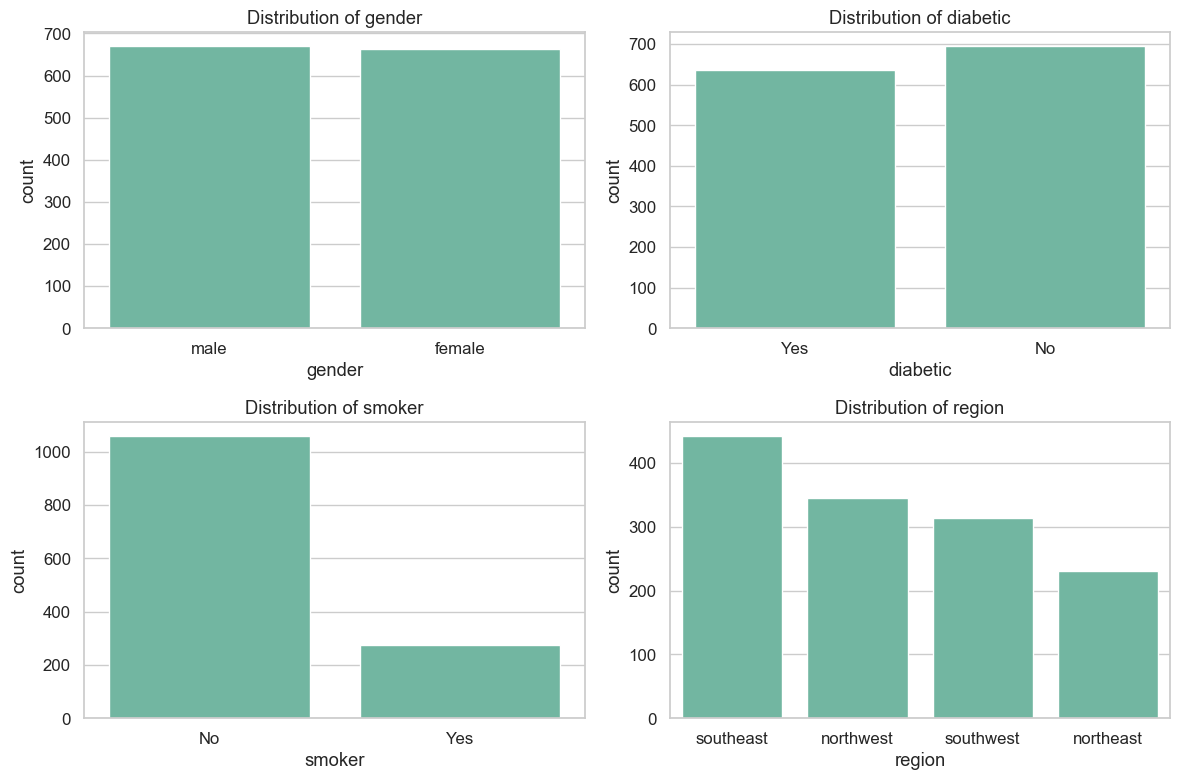

In [24]:
cat_cols = ["gender", "diabetic", "smoker", "region"]

plt.figure(figsize=(12,8))

for i, col in enumerate(cat_cols,1):
    plt.subplot(2,2,i)
    sns.countplot(data = df, x = col)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

In [25]:
df.groupby(["gender", "smoker"])["claim"].mean().round(2)

gender  smoker
female  No        8762.30
        Yes      30679.00
male    No        8169.25
        Yes      33042.01
Name: claim, dtype: float64

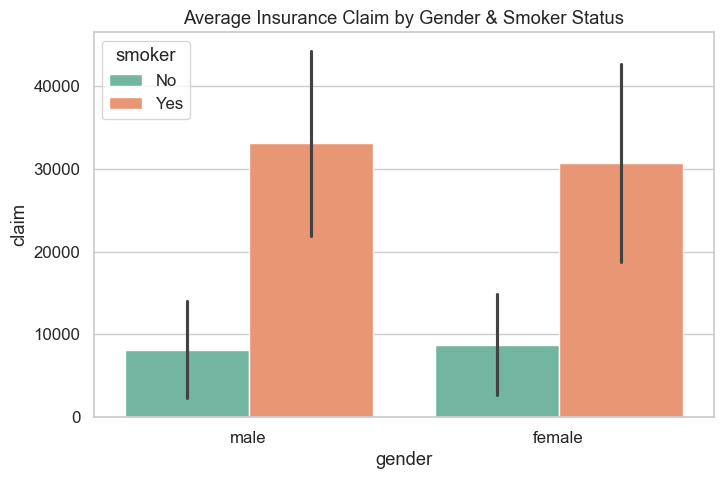

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="gender", y="claim", hue="smoker", estimator= "mean", errorbar = "sd")
plt.title("Average Insurance Claim by Gender & Smoker Status")
plt.show()

In [27]:
pivot_region_diabetic = df.groupby(["region","diabetic"])["claim"].mean().unstack()

In [28]:
pivot_region_diabetic

diabetic,No,Yes
region,,
northeast,16966.86,16818.30
northwest,11442.83,12224.96
southeast,13578.72,12574.09
southwest,13069.91,12313.74


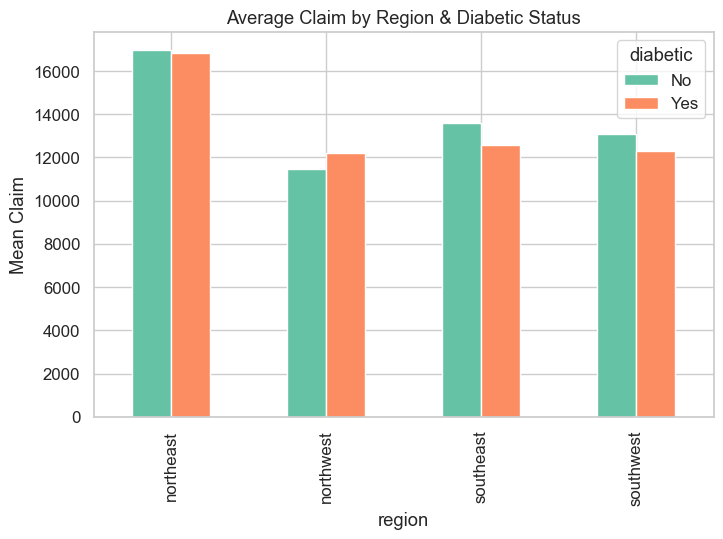

In [29]:
pivot_region_diabetic.plot(kind = "bar", figsize=(8,5))
plt.title("Average Claim by Region & Diabetic Status")
plt.ylabel("Mean Claim")
plt.show()

In [30]:
pivot__table = pd.pivot_table(df, values="claim",index="region", columns= "smoker", aggfunc="mean")
pivot__table

smoker,No,Yes
region,,
northeast,11666.11,29673.54
northwest,8076.20,30192.00
southeast,7444.14,34845.00
southwest,8294.75,32269.06


In [31]:
pivot_table = df.pivot_table(values= "claim", index = "children", columns = "diabetic", aggfunc="mean")
pivot_table

diabetic,No,Yes
children,,
0,12967.40,11985.29
1,12730.46,12732.06
2,15567.77,14579.36
3,13807.61,17091.26
4,14106.63,13573.35
5,8519.04,9205.59


In [32]:
df[numeric_cols].corr()

,age,bmi,bloodpressure,children,claim
age,1.00,-0.04,-0.06,-0.03,-0.03
bmi,-0.04,1.00,0.14,0.01,0.20
bloodpressure,-0.06,0.14,1.00,-0.03,0.53
children,-0.03,0.01,-0.03,1.00,0.06
claim,-0.03,0.20,0.53,0.06,1.00


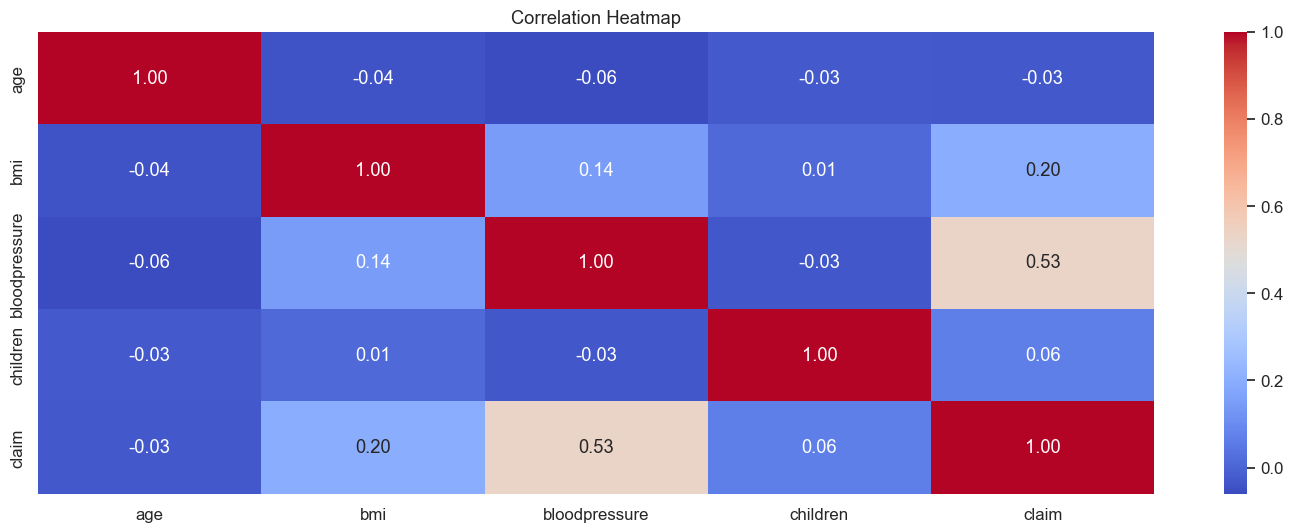

In [33]:
plt.figure(figsize=(18,6))
sns.heatmap(df[numeric_cols].corr(),annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

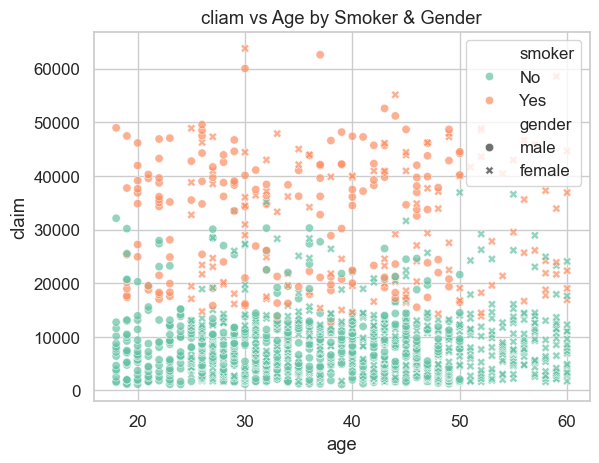

In [34]:
sns.scatterplot(data = df, x = "age", y = "claim", hue = "smoker", style="gender",alpha = 0.7)
plt.title("cliam vs Age by Smoker & Gender")
plt.show()

Text(0.5, 1.0, 'Relationship between BMI and Claim Amount')

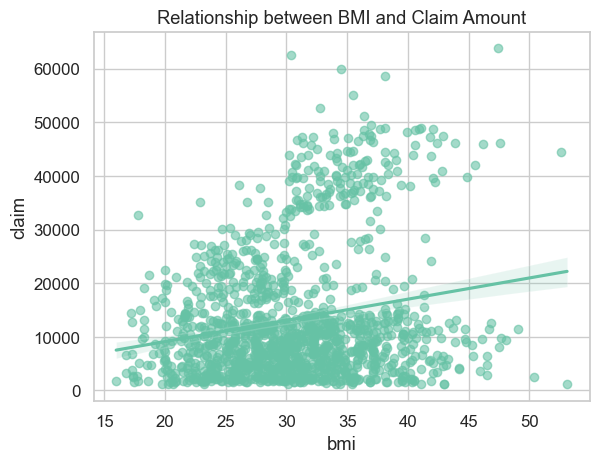

In [35]:
sns.regplot(data = df, x = "bmi", y = "claim", scatter_kws={"alpha":0.6})
plt.title("Relationship between BMI and Claim Amount")

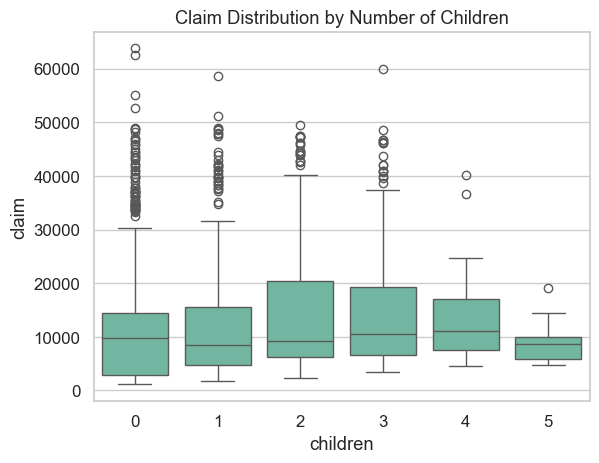

In [36]:
sns.boxplot(data = df, x = "children", y = "claim")
plt.title("Claim Distribution by Number of Children")
plt.show()

In [37]:
df["age_group"] = pd.cut(df["age"], bins=[0,18,30,45,60,100], labels=["0-18","19-30","31-45","46-60","60+"])

In [38]:
df

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,age_group
0,1,39.00,male,23.20,91,Yes,0,No,southeast,1121.87,31-45
1,2,24.00,male,30.10,87,No,0,No,southeast,1131.51,19-30
7,8,19.00,male,41.10,100,No,0,No,northwest,1146.80,19-30
8,9,20.00,male,43.00,86,No,0,No,northwest,1149.40,19-30
9,10,30.00,male,53.10,97,No,0,No,northwest,1163.46,19-30
...,...,...,...,...,...,...,...,...,...,...,...
1335,1336,44.00,female,35.50,88,Yes,0,Yes,northwest,55135.40,31-45
1336,1337,59.00,female,38.10,120,No,1,Yes,northeast,58571.07,46-60
1337,1338,30.00,male,34.50,91,Yes,3,Yes,northwest,60021.40,19-30
1338,1339,37.00,male,30.40,106,No,0,Yes,southeast,62592.87,31-45


In [39]:
df["age_group"].value_counts()

age_group
31-45    553
46-60    383
19-30    380
0-18      16
60+        0
Name: count, dtype: int64

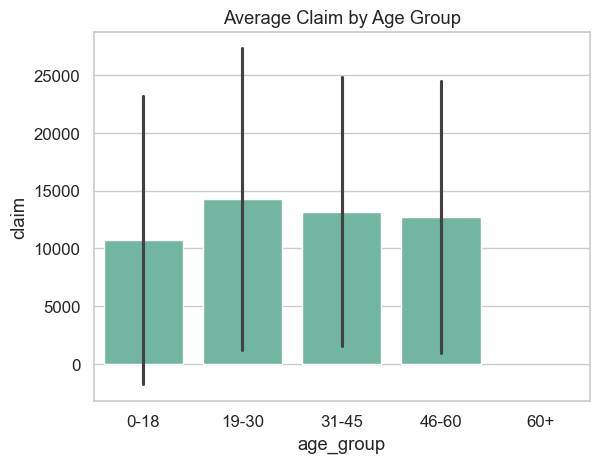

In [40]:
sns.barplot(data=df, x="age_group", y="claim", estimator="mean", errorbar="sd")
plt.title("Average Claim by Age Group")
plt.show()

In [41]:
df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, 100], labels=["Underweight","Normal","Overweight","Obese"])


In [42]:
df["bmi_category"].value_counts()

bmi_category
Obese          693
Overweight     391
Normal         227
Underweight     21
Name: count, dtype: int64

In [43]:
import warnings
warnings.filterwarnings("ignore")

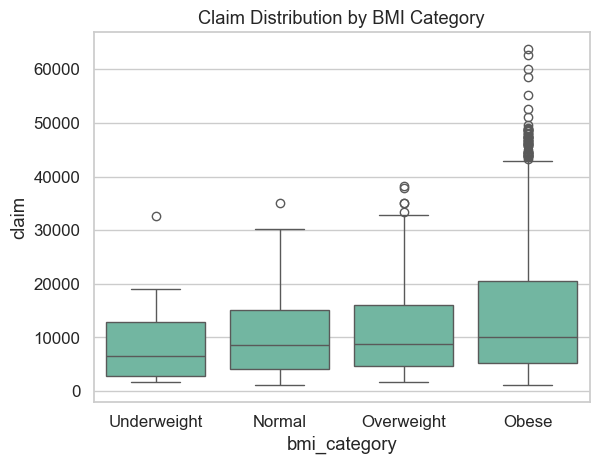

In [44]:
sns.boxplot(data = df, x = "bmi_category", y = "claim",)
plt.title("Claim Distribution by BMI Category")
plt.show()

In [45]:
region_stats = df.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x=="yes").mean()* 100),
    mean_claim = ("claim", "mean")
).reset_index()

In [46]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,0.00,16889.04
1,northwest,0.00,11794.22
2,southeast,0.00,13085.50
3,southwest,0.00,12723.13


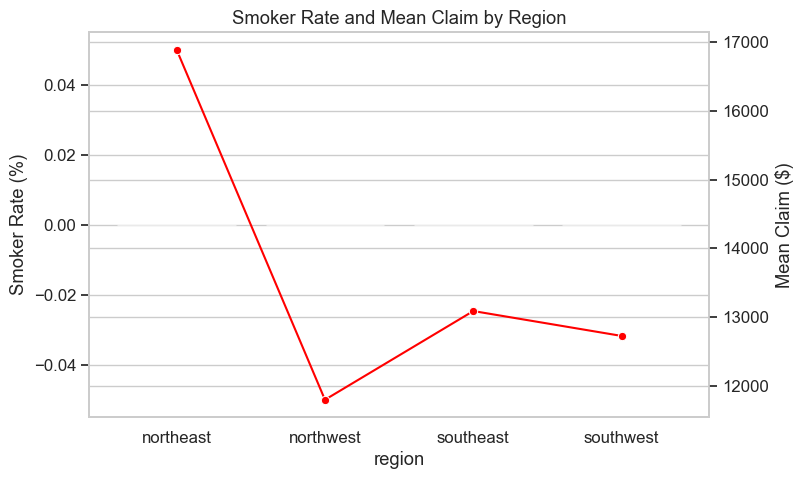

In [47]:
fig, ax1 = plt.subplots(figsize=(8,5))
sns.barplot(data = region_stats, x="region", y="smoker_rate",ax= ax1, alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats, x="region", y="mean_claim", ax=ax2, color="red",marker="o",)

ax1.set_ylabel("Smoker Rate (%)" )
ax2.set_ylabel("Mean Claim ($)")
plt.title("Smoker Rate and Mean Claim by Region") 
plt.show()

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

In [54]:
df.columns

Index(['Id', 'age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'region', 'claim'],
      dtype='object')

In [56]:
X= df[["age","gender","bmi","bloodpressure","diabetic","children","smoker"]]
y= df[["claim"]]

In [57]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,male,23.20,91,Yes,0,No
1,24.00,male,30.10,87,No,0,No
2,NaN,male,33.30,82,Yes,0,No
3,NaN,male,33.70,80,No,0,No
4,NaN,male,34.10,100,No,0,No
...,...,...,...,...,...,...,...
1335,44.00,female,35.50,88,Yes,0,Yes
1336,59.00,female,38.10,120,No,1,Yes
1337,30.00,male,34.50,91,Yes,3,Yes
1338,37.00,male,30.40,106,No,0,Yes


In [58]:
cat_cols =["gender","diabetic","smoker"]
label_encoders = {}

In [68]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoders_{col}.pkl")
    
    

In [69]:
X

,age,gender,bmi,bloodpressure,diabetic,children,smoker
0,39.00,1,23.20,91,1,0,0
1,24.00,1,30.10,87,0,0,0
2,NaN,1,33.30,82,1,0,0
3,NaN,1,33.70,80,0,0,0
4,NaN,1,34.10,100,0,0,0
...,...,...,...,...,...,...,...
1335,44.00,0,35.50,88,1,0,1
1336,59.00,0,38.10,120,0,1,1
1337,30.00,1,34.50,91,1,3,1
1338,37.00,1,30.40,106,0,0,1


In [70]:
label_encoders

{'gender': LabelEncoder(),
 'diabetic': LabelEncoder(),
 'smoker': LabelEncoder()}

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [72]:
num_cols = []

In [76]:
num_cols = ["age", "bmi", "bloodpressure", "children"]
scalar = StandardScaler()


In [79]:
X_train[num_cols] = scalar.fit_transform(X_train[num_cols])
X_test[num_cols] = scalar.transform(X_test[num_cols])

In [80]:
joblib.dump(scalar, "scaler.pkl")


['scaler.pkl']

In [81]:
print(X_train.shape, y_train.shape)

(1072, 7) (1072, 1)


In [82]:
print(X_test.shape, y_test.shape)

(268, 7) (268, 1)


In [15]:
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble  import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor


In [3]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return {"R2" : r2, "MAE": mae, "RMSE" : rmse}
    

In [4]:
results = {}

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib


In [17]:
from sklearn.model_selection import train_test_split
try:
    X_train
except NameError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
results["Linear Regression"] = evaluate_model(lr, X_train, X_test, y_train, y_test)
print("Linear Regression model trained")

best_poly_model = None
best_poly_score = -np.inf

for degree in [2,3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    poly_lr = LinearRegression()
    poly_lr.fit(X_train_poly, y_train)
    
    score = poly_lr.score(X_test_poly, y_test)
    
    if score > best_poly_score:
        best_poly_score = score
        best_poly_model = (degree, poly, poly_lr)

degree, poly, poly_lr = best_poly_model
results[f"Polynomial Regression (deg={degree})"] = evaluate_model(poly_lr, poly.fit_transform(X_train), poly.transform(X_test), y_train, y_test)
print(f"Polynomial Regression model trained")

rf = RandomForestRegressor()

rf_params = {
    "n_estimators": [100,200],
    "max_depth": [None,10,20],
    "min_samples_split": [2,5],
    "min_samples_leaf": [1,2]
}

rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
rf_grid.fit(X_train, y_train.values.ravel())
best_rf = rf_grid.best_estimator_

results["Random Forest"] = evaluate_model(best_rf, X_train, X_test, y_train, y_test)

print("Random Forest training is completed, best parameters:", rf_grid.best_params_)

svr = SVR()

svr_params = {
    "kernel": ["rbf","poly", "linear"],
    "C": [1,10,50],
    "epsilon":[0.1,0.2,0.5],
    "degree":[2,3]
}
svr_grid = GridSearchCV(svr, svr_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
svr_grid.fit(X_train, y_train.values.ravel())
best_svr = svr_grid.best_estimator_

results["SVR"] = evaluate_model(best_svr, X_train, X_test, y_train, y_test)

print("SVR training is completed, best parameters:", svr_grid.best_params_)

xgb = XGBRegressor()

xgb_params = {
    "n_estimators": [100,200],
    "max_depth": [3,5,7],
    "learning_rate": [0.01,0.1,0.2],
    "subsample": [0.8,1.0],
}
xgb_grid = GridSearchCV(xgb, xgb_params, cv=3, scoring="r2", n_jobs=-1, verbose=0)
xgb_grid.fit(X_train, y_train.values.ravel())
best_xgb = xgb_grid.best_estimator_

results["XGBoost"] = evaluate_model(best_xgb, X_train, X_test, y_train, y_test)

print("XGBoost training is completed, best parameters:", xgb_grid.best_params_)


NameError: name 'X_train' is not defined

In [18]:
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

    joblib.dump(le, f"label_encoders_{col}.pkl")
    

NameError: name 'cat_cols' is not defined